<a href="https://colab.research.google.com/github/VasilinaFrolova/-/blob/main/%D0%A1%D0%BF%D0%B8%D1%80%D0%BC%D0%B5%D0%BD_%D0%90%D0%B2%D1%82%D0%BE%D1%80%2B%D0%A1%D1%83%D0%B1%D1%8A%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
from scipy.stats import spearmanr
import re

In [ ]:
# 1. Загрузка файла
print("Загрузите файл 'Спирмен_объект+субъет.xlsx'")
uploaded = files.upload()
file_name = next(iter(uploaded))
print(f"Файл {file_name} загружен")

Загрузите файл 'Спирмен_объект+субъет.xlsx'


Saving Спирмен_объект+субъет.xlsx to Спирмен_объект+субъет (1).xlsx
Файл Спирмен_объект+субъет (1).xlsx загружен


In [ ]:
# 2. Чтение листов
xls = pd.ExcelFile(file_name)
sheet_names = xls.sheet_names
print("Листы:", sheet_names)

Листы: ['Объективные_характеристики', 'суб.убедительность и приобрет.', 'суб.запоминаемость и приобрет.', 'суб.внимание и приобрет.', 'суб. сильная эмоц. и приобрет.', 'суб. убедит. и запоминаемость']


In [ ]:
# 3. Сбор субъективных оценок со всех листов, кроме 'Объективные_характеристики'
subj_sheets = [s for s in sheet_names if s != 'Объективные_характеристики']

# Создадим единый DataFrame для субъективных данных
df_subj_all = None

for sheet in subj_sheets:
    df = pd.read_excel(file_name, sheet_name=sheet)
    # Берём только столбцы, связанные с оценками реклам (Б1_..., Б2_...)
    cols = [c for c in df.columns if re.match(r'Б\d+_', c)]
    if not cols:
        continue
    # Добавляем к общему DataFrame, избегая дублирования столбцов
    if df_subj_all is None:
        df_subj_all = df[cols].copy()
    else:
        for c in cols:
            if c not in df_subj_all.columns:
                df_subj_all[c] = df[c]

print(f"Собрано {df_subj_all.shape[1]} признаков субъективных оценок")

Собрано 50 признаков субъективных оценок


In [ ]:
# 4. Преобразование в мультииндекс (реклама, метрика)
# Разделим имена столбцов по первому подчёркиванию
new_cols = []
for col in df_subj_all.columns:
    match = re.match(r'(Б\d+)_(.*)', col)
    if match:
        banner = int(match.group(1).lstrip('Б'))   # номер рекламы
        metric = match.group(2)                     # название метрики
        new_cols.append((banner, metric))
df_subj_all.columns = pd.MultiIndex.from_tuples(new_cols, names=['Реклама', 'Метрика'])

In [ ]:
# 5. Расчёт средних субъективных оценок по каждому баннеру
# Среднее по респондентам (строки) для каждого (Реклама, Метрика)
subj_means_series = df_subj_all.mean()   # мультииндекс Series
# Преобразуем в DataFrame: строки – рекламы, столбцы – метрики
subj_means = subj_means_series.unstack(level='Метрика')
subj_means.index = subj_means.index.astype(int)

print("Средние субъективные оценки по рекламам:")
print(subj_means)

Средние субъективные оценки по рекламам:
Метрика  Внимание  Запоминаемость  Приобретение  Убедительность    Эмоция
Реклама                                                                  
1        2.451923        2.836538      1.846154        2.394231  2.105769
2        3.163462        3.288462      2.442308        3.057692  2.903846
3        2.644231        2.759615      2.451923        3.163462  2.451923
4        2.278846        2.586538      2.221154        2.384615  2.394231
5        2.567308        2.490385      1.894231        2.230769  2.413462
6        2.144231        2.240385      2.105769        2.500000  2.067308
7        3.000000        2.817308      2.615385        2.875000  2.519231
8        3.644231        3.769231      3.125000        3.365385  3.490385
9        2.413462        2.336538      2.076923        2.326923  2.057692
10       3.307692        3.375000      3.375000        3.625000  3.240385


In [ ]:
# 6. Чтение объективных характеристик
df_obj = pd.read_excel(file_name, sheet_name='Объективные_характеристики')
df_obj = df_obj.set_index('Реклама')
print("\nОбъективные характеристики (первые строки):")
print(df_obj.head())


Объективные характеристики (первые строки):
         Emotional_Impact  Memorability_Index  Persuasiveness_Score  \
Реклама                                                               
1                       4                   5                     3   
2                       5                   4                     4   
3                       2                   2                     3   
4                       4                   4                     4   
5                       3                   5                     4   

         Attention_Score  Behavioral_Intention  Императив  Тональность  \
Реклама                                                                  
1                      4                     2          0            2   
2                      3                     4          1            1   
3                      2                     2          0            1   
4                      4                     4          1            1   
5            

In [ ]:
# 7. Объединение
df_combined = df_obj.join(subj_means, how='inner')
print("\nОбъединённые данные (первые строки):")
print(df_combined.head())


Объединённые данные (первые строки):
         Emotional_Impact  Memorability_Index  Persuasiveness_Score  \
Реклама                                                               
1                       4                   5                     3   
2                       5                   4                     4   
3                       2                   2                     3   
4                       4                   4                     4   
5                       3                   5                     4   

         Attention_Score  Behavioral_Intention  Императив  Тональность  \
Реклама                                                                  
1                      4                     2          0            2   
2                      3                     4          1            1   
3                      2                     2          0            1   
4                      4                     4          1            1   
5                   

In [ ]:
# 8. Корреляции Спирмена
results = []
obj_cols = df_obj.columns.tolist()
subj_cols = subj_means.columns.tolist()

for obj in obj_cols:
    for subj in subj_cols:
        valid = df_combined[[obj, subj]].dropna()
        if len(valid) < 3:
            rho, p = float('nan'), float('nan')
        else:
            rho, p = spearmanr(valid[obj], valid[subj])
        results.append({
            'Объективный признак': obj,
            'Субъективная метрика': subj,
            'Спирмен ρ': round(rho, 4) if pd.notna(rho) else None,
            'p-значение': round(p, 4) if pd.notna(p) else None
        })

df_corr = pd.DataFrame(results)
print("\nКорреляции Спирмена (объективные vs субъективные):")
print(df_corr.to_string(index=False))


Корреляции Спирмена (объективные vs субъективные):
 Объективный признак Субъективная метрика  Спирмен ρ  p-значение
    Emotional_Impact             Внимание     0.5212      0.1224
    Emotional_Impact       Запоминаемость     0.7437      0.0137
    Emotional_Impact         Приобретение     0.2161      0.5487
    Emotional_Impact       Убедительность     0.3305      0.3509
    Emotional_Impact               Эмоция     0.5784      0.0798
  Memorability_Index             Внимание     0.3210      0.3657
  Memorability_Index       Запоминаемость     0.4944      0.1463
  Memorability_Index         Приобретение    -0.1734      0.6320
  Memorability_Index       Убедительность    -0.0514      0.8879
  Memorability_Index               Эмоция     0.3275      0.3557
Persuasiveness_Score             Внимание     0.1421      0.6953
Persuasiveness_Score       Запоминаемость     0.1421      0.6953
Persuasiveness_Score         Приобретение     0.0711      0.8453
Persuasiveness_Score       Убедительно

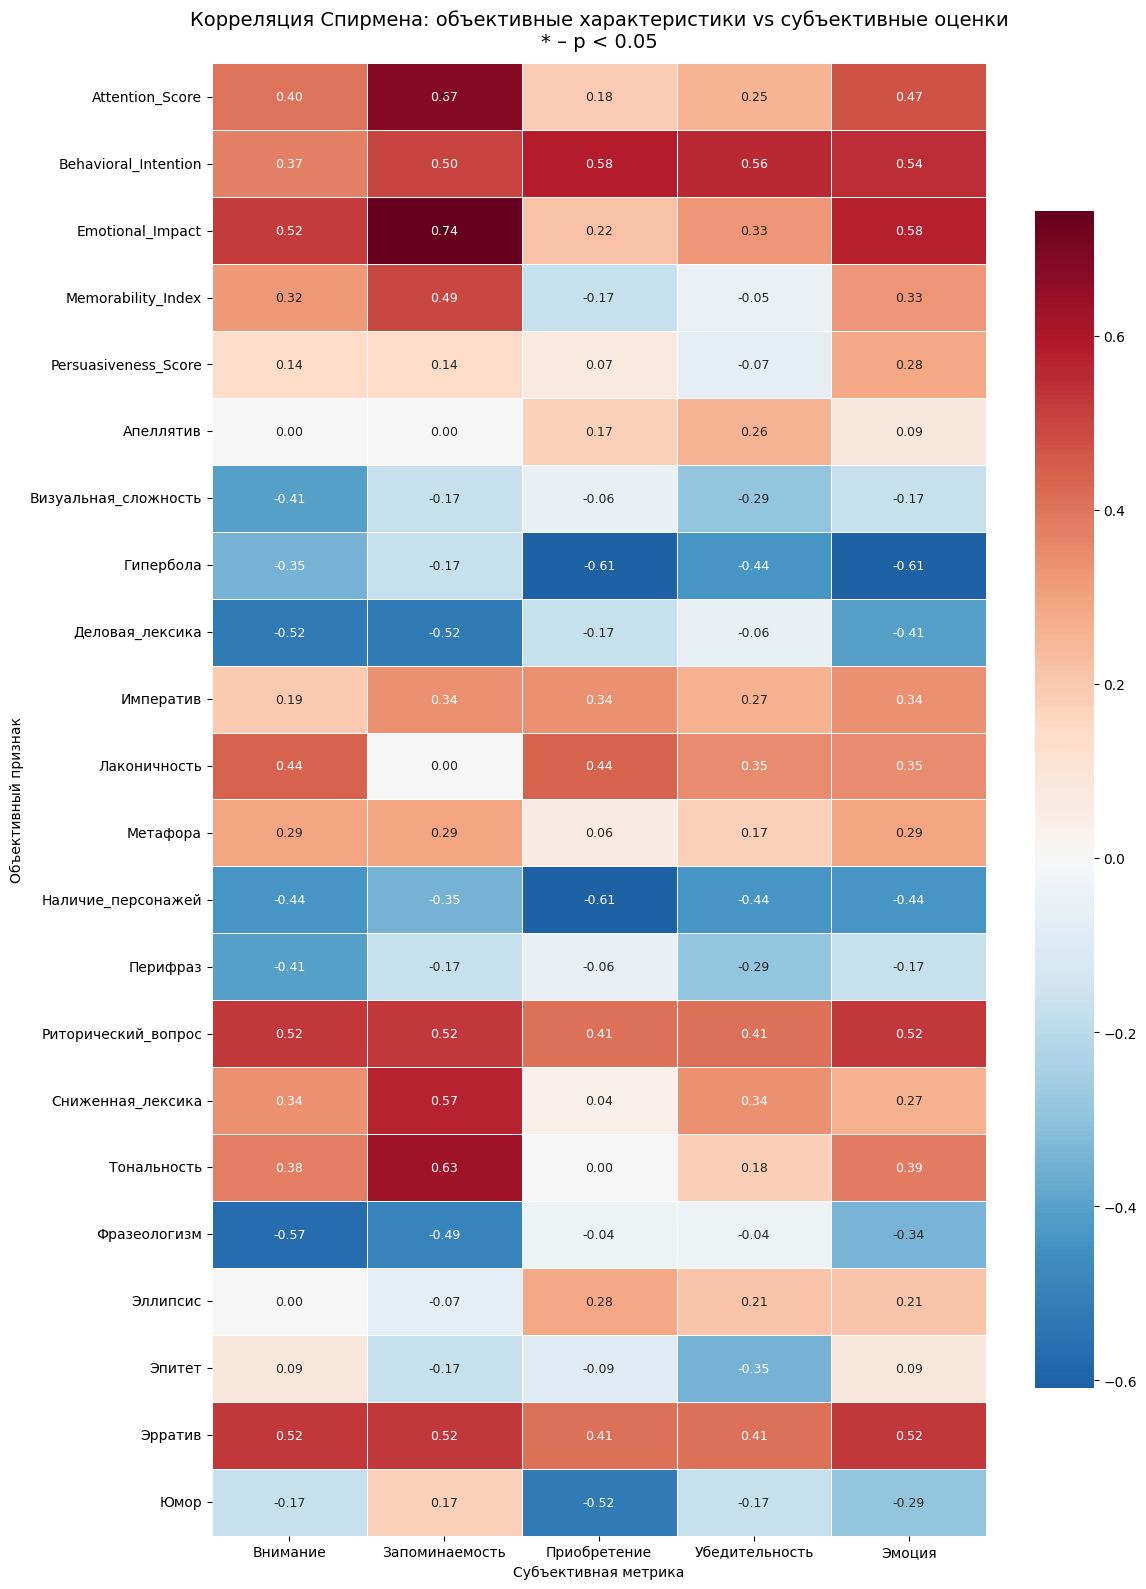

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Преобразуем df_corr в матрицу: строки – объективные признаки, столбцы – субъективные метрики
corr_matrix = df_corr.pivot(index='Объективный признак',
                            columns='Субъективная метрика',
                            values='Спирмен ρ')

# Построим маску значимости (p < 0.05) для выделения
pivot_p = df_corr.pivot(index='Объективный признак',
                        columns='Субъективная метрика',
                        values='p-значение')
annot_mask = pivot_p < 0.05

# Размер тепловой карты
plt.figure(figsize=(12, 16))

# Тепловая карта
sns.heatmap(corr_matrix,
            annot=True,                # подписываем коэффициенты
            fmt='.2f',
            cmap='RdBu_r',             # красно-синяя палитра
            center=0,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            mask=None,                 # показываем все ячейки
            annot_kws={'size': 9})

# Выделяем значимые корреляции звёздочкой
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if annot_mask.iloc[i, j]:
            plt.text(j + 0.5, i + 0.5, '*', ha='center', va='center',
                     fontsize=8, fontweight='bold')

plt.title('Корреляция Спирмена: объективные характеристики vs субъективные оценки\n* – p < 0.05',
          fontsize=14, pad=12)
plt.ylabel('Объективный признак')
plt.xlabel('Субъективная метрика')
plt.tight_layout()
plt.show()

In [ ]:
# 9. Сохранение
output_file = 'obj_subj_corr_results.xlsx'
with pd.ExcelWriter(output_file) as writer:
    df_obj.to_excel(writer, sheet_name='Объективные')
    subj_means.to_excel(writer, sheet_name='Субъективные_средние')
    df_combined.to_excel(writer, sheet_name='Объединённые')
    df_corr.to_excel(writer, sheet_name='Корреляции')

print(f"\nРезультаты сохранены в файл: {output_file}")


Результаты сохранены в файл: obj_subj_corr_results.xlsx


In [ ]:
# Сохраняем график в файл
plt.savefig('heatmap_объект_субъект.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig('heatmap.pdf', format='pdf', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>